In [1]:
# import classy module
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

In [2]:
# import plot and numpy modules VF

#%matplotlib inline
#%matplotlib qt
#%matplotlib notebook

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as tck

import numpy as np

from scipy.interpolate import interp1d

# remove frame of legends VF
boolean = False

In [3]:
import matplotlib.font_manager as fm
# Collect all the font names available to matplotlib
font_names = [f.name for f in fm.fontManager.ttflist]

In [4]:
# Turn output of scales into a string and not a vector - useful for other quantities as well

k_scale=[0.125*0.67556]
output_k=''
for i in k_scale:
    output_k+=str(i)+','
output_k = output_k[:-1]
print(output_k)

0.084445


In [12]:
deltas = [1e-5,1e-3,-1e-3]

scf_parameters = []
for i in range(0, len(deltas)):
    scf_parameters.append('1.'+','+'1.'+','+str(deltas[i])+','+'1.'+','+'-0.000000000008')
print(scf_parameters)
print(len(scf_parameters))

['1.,1.,1e-05,1.,-0.000000000008', '1.,1.,0.001,1.,-0.000000000008', '1.,1.,-0.001,1.,-0.000000000008']
3


In [13]:
# Run standard LCDM class for comparison with other plots

standard = Class()
#standard.set({'Omega_Lambda':0, 'Omega_fld':0, 'Omega_scf':-1, 'attractor_ic_scf':'no','scf_tuning_index':1,
 #             'scf_parameters':parameters,'output':'tCl,mPk','P_k_max_1/Mpc':1.0,
  #            'k_output_values':output_k,'write background':'yes','evolver':0.})
standard.set({# wich output? ClTT, transfer functions delta_i and theta_i
                   'output':'tCl,pCl,lCl,mPk',
                   'lensing':'yes',
                   # LambdaCDM parameters
                   'h':0.67556,
                   'omega_b':0.022032,
                   'omega_cdm':0.12038,
                    #'Omega_Lambda':0.,
                    'Omega_fld':0.,
                    'Omega_scf':0.,
                    #'scf_parameters': '1., 1., 1e-10, 1., 0.',
                   # 'attractor_ic_scf':'no',
                   # 'scf_tuning_index': 1,
                   'A_s':2.215e-9,
                   'n_s':0.9619,
                   'tau_reio':0.0925,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':0.246,
                   # other output and precision parameters
                   'P_k_max_1/Mpc':1.0,'l_max_scalars':5000,'k_output_values':output_k,'write background':'yes','evolver':0.})

standard.compute()
standard_background = standard.get_background()

In [14]:
##########################################################################################################################

#                                                       V 2.9

##########################################################################################################################

cosmo = [1] * len(deltas)
cosmo_background = [1] * len(deltas)
cosmo_perturbations = [1] * len(deltas)
for index in range(0,len(deltas)):
    parameters = scf_parameters[index]
    print(scf_parameters[index])
    cosmo[index] = Class()
    cosmo[index].set({'output':'tCl,pCl,lCl,mPk','lensing':'yes',
                   # LambdaCDM parameters
                   'h':0.67556,'omega_b':0.022032,'omega_cdm':0.12038,'Omega_Lambda':0.,'Omega_fld':0.,
                    'Omega_scf':-1.,'scf_parameters': parameters,'attractor_ic_scf':'no','scf_tuning_index': 1,
                   'A_s':2.215e-9,'n_s':0.9619,'tau_reio':0.0925,'YHe':0.246,
                   # other output and precision parameters
                   'P_k_max_1/Mpc':1.0,'l_max_scalars':5000,'k_output_values':output_k,
                    'write background':'yes','evolver':0.,'z_max_pk':10.})
    
    cosmo[index].compute()
    cosmo_background[index] = cosmo[index].get_background()
    cosmo_perturbations[index] = cosmo[index].get_perturbations()

cosmo_background[0].keys()
cosmo_perturbations[0].keys()

1.,1.,1e-05,1.,-0.000000000008
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
1.,1.,0.001,1.,-0.000000000008
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
1.,1.,-0.001,1.,-0.000000000008
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using

dict_keys(['scalar'])

In [15]:
cosmo_background[0].keys()

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_ur', '(.)rho_crit', '(.)rho_scf', '(.)p_scf', '(.)p_prime_scf', 'phi_scf', "phi'_scf", 'V_scf', "V'_scf", "V''_scf", '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])

In [9]:
cosmo_perturbations[0]['scalar'][0].keys()

dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'delta_scf', 'theta_scf'])

In [10]:
for idx in range(0,len(deltas)):
    my_cosmo = cosmo[idx]
    print('\delta_s =  = {} --> V_0 = {}'.format(deltas[idx],my_cosmo.V0_scf()))

AttributeError: 'classy.Class' object has no attribute 'V0_scf'

In [ ]:
(cosmo_background[idx]['Q_scf'][-1])*(cosmo_background[idx]['phi_scf'][-1])/(cosmo_background[idx]['(.)rho_cdm'][-1])

KeyError: 'Q_scf'

In [ ]:
print(standard.sigma(8/standard.h(),0))
idx = 0
for idx in range(0,len(deltas)):
    my_cosmo = cosmo[idx]
    print(my_cosmo.sigma8())

0.8487264865865901
0.8294068452717118
0.8293665050131952
0.7912271462662724


In [ ]:
print(standard.scale_independent_growth_factor_f(0)*standard.sigma8())
idx = 0
for idx in range(0,len(deltas)):
    my_cosmo = cosmo[idx]
    print(my_cosmo.scale_independent_growth_factor_f(0)*my_cosmo.sigma8())

0.44497971660858393
0.4330260728750785
0.43300501157829296
0.41309278534781935


In [ ]:
conversion = 7.4e-40
idx = 0
for idx in range(0,len(deltas)):
    print(cosmo_background[idx]['(.)rho_cdm'][0]*conversion)
    print(cosmo_background[idx]['phi_scf'][0])

9.911620217332398e-06
1.0
9.911620217332398e-06
1.0
9.911620217332398e-06
1.0


In [ ]:
conversion = 7.4e-40
scf_g = 10**-8
tau0 = 4.634785000235*10-9
a0 = 10**-14
Mp =  2.435*10**18
phip = -scf_g*tau0/(2*a0*Mp)

for idx in range(0,len(deltas)):
    my_cosmo = cosmo[idx]
    guess = scf_g * deltas[idx]/(3*(10**-14)**3)
    g_guess = cosmo_background[idx]['(.)rho_cdm'][0]*(10**-14)**3/(deltas[idx])
    g_guess2 = cosmo_background[idx]['(.)rho_cdm'][-1]*(1.)**3/(cosmo_background[idx]['phi_scf'][-1])
    print('phi_i = {} --> rho_0 = {} --> g = {}'.format(deltas[idx],cosmo_background[idx]['(.)rho_cdm'][0],g_guess))
    print('phi_i = {} --> rho_t = {} --> g = {}'.format(deltas[idx],cosmo_background[idx]['(.)rho_cdm'][-1],g_guess2))    

phi_i = 1e-10 --> rho_0 = 1.339408137477351e+34 --> g = 133.9408137477351
phi_i = 1e-10 --> rho_t = 1.339408137477346e-08 --> g = 1.0181525290365097e-08
phi_i = 1e-05 --> rho_0 = 1.339408137477351e+34 --> g = 0.001339408137477351
phi_i = 1e-05 --> rho_t = 1.339408137477346e-08 --> g = 1.0181525290365097e-08
phi_i = 0.01 --> rho_0 = 1.339408137477351e+34 --> g = 1.3394081374773512e-06
phi_i = 0.01 --> rho_t = 1.339408137477346e-08 --> g = 1.0181525290365097e-08


In [ ]:
# VF think a bit more about these definitions

k0=0.1
dz = 0.01
hstep=0.001
#Make a mock array; this will contain the redshifts z\in[0,2,0.01] we need for the interpolation
zed = np.arange(0.0, 2.0,dz)
#Make a mock array; this will contain f(k,z) at z\in[0,2]
scale_growthf=np.arange(0.0, 2.0,dz)
#Make a mock array; this will contain P(k,z) at z\in[0,2]
Pkz=np.arange(0.0,2.0,dz)
# Get the P(k,z) from CLASS and interpolate
for zz in range(len(zed)):
    Pkz[zz]=my_cosmo.pk(k0,zed[zz])
    Pkint=interp1d(zed,Pkz,kind='cubic')
# Calculate the growth via f=-0.5*(1+z)*D[Log[P(k,z),z] with a simple difference and interpolate
for zz in range(len(zed)-1):
# One point numerical derivative (forward difference)
    scale_growthf[zz]=-0.5*(1+zed[zz])*(Pkint(zed[zz]+hstep)-Pkint(zed[zz]))/hstep/Pkint(zed[zz])
    scale_growthfint=interp1d(zed,scale_growthf,kind='cubic',fill_value="extrapolate")

/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_98441/3653503073.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


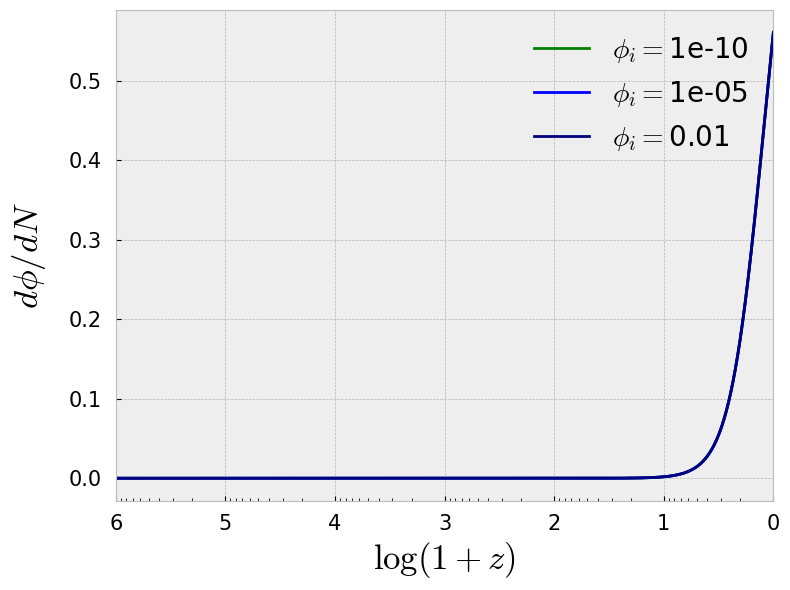

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.style.use('bmh')

lw = 1.
#ls = ['--', '-.', ':']
color = ['g','b','navy','r']

i=0
for idx in [0,1,2]:
    my_cosmo = cosmo[idx]
    a = 1./(1.+cosmo_background[idx]['z'])
    H = cosmo_background[idx]['H [1/Mpc]']
    ax.plot(1.+cosmo_background[idx]['z'], 1./a*cosmo_background[idx]["phi'_scf"]/H,
           label = r'$\delta_s =  $'+str(deltas[idx]),c=color[i])
    
    i+=1
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_xlim(1e6,1.)
#ax.set_ylim(-0.8,0.8)
ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'${d\phi/dN}$', labelpad=15, size=25)

ax.tick_params(axis='both', which='both', labelsize=15)

for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)

original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

plt.legend(loc='best', frameon=boolean, prop={'size': 20})

fig.tight_layout()
plt.savefig('phiprime_late.pdf', transparent=True)

phi'_i = -8e-12
phi'_0 = 0.00012635241619329777


AttributeError: 'classy.Class' object has no attribute 'a_eq'

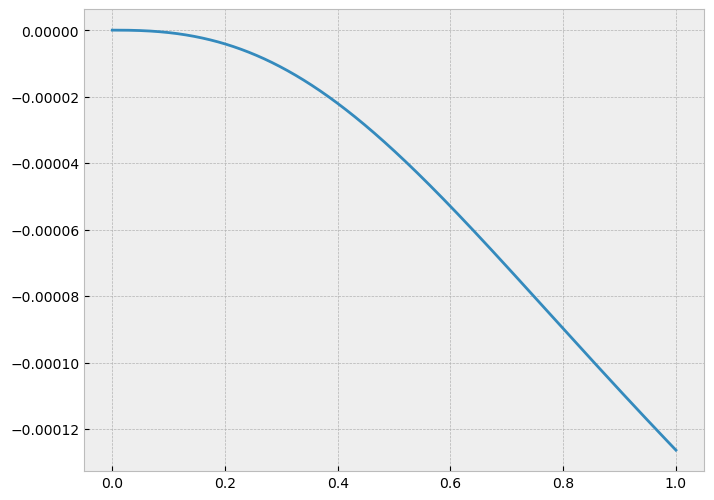

In [ ]:
c = 299792.458 # km/s

idx = 1
print("phi'_i =", cosmo_background[idx]["phi'_scf"][0])
print("phi'_0 =", cosmo_background[idx]["phi'_scf"][-1])

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.style.use('bmh')

a = 1./(1.+cosmo_background[idx]['z'])
my_cosmo=cosmo[idx]

#K = 3.*(betav[idx]*(my_cosmo.Omega0_cdm())*cosmo_background[idx]['(.)rho_crit'][-1] \
#/ np.sqrt((cosmo_background[idx]['(.)rho_g'][-1]+cosmo_background[idx]['(.)rho_ur'][-1])))
#print K
#print 3.*betav[idx]*my_cosmo.h()*100.*my_cosmo.Omega0_cdm()/np.sqrt(my_cosmo.Omega_r())/c

ax.plot(a, -cosmo_background[idx]["phi'_scf"])
my_cosmo = cosmo[idx]
z_eq = int(1/my_cosmo.a_eq()-1.)
#ax.axvline(z_eq, c='orange', ls=':', lw=2) # ----------------------------------> Matter-radiation equality
ax.axhline(-cosmo_background[idx]["phi'_scf"][0], c='orange', ls=':', lw=2) # -----> phi'_i
ax.plot(a, (10**-4)*(10**-14/a)**-2)
ax.plot(a, (10**-3)*(10**-2/a)**(1/2))


#ax.plot(1.+cosmo_background[idx]['z'], cosmo_background[idx]["phi'_scf"][-1]*a**(-0.5))

ax.set_xscale('log')
ax.set_yscale('log')

#ax.set_xlim(1e14,1.)
ax.set_ylim(1e-6,2)
ax.set_xlabel(r'$\log(a)$', size=25)
ax.set_ylabel(r'$\log\,-\phi^\prime$', labelpad=15, size=25)

ax.tick_params(axis='both', which='both', labelsize=15)

for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)

original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

fig.tight_layout()
#plt.savefig('cq_phi_prime.pdf', transparent=True)
plt.show()

1e-10


AttributeError: 'classy.Class' object has no attribute 'a_eq'

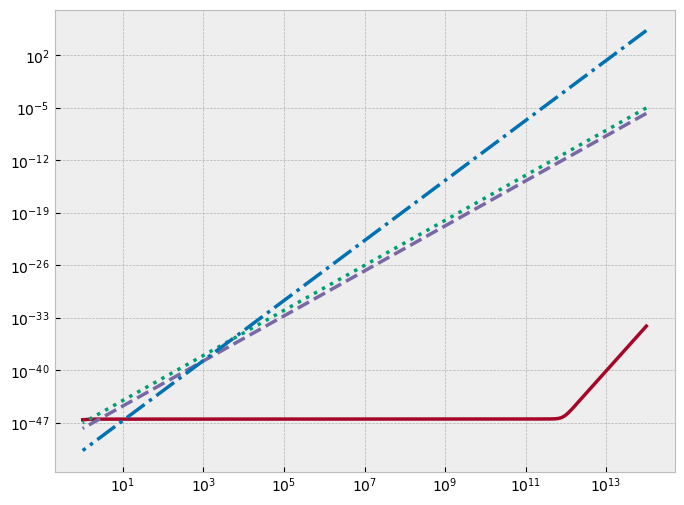

In [ ]:
conversion = 7.4e-40 #----------------------------------------------> CONVERSION GEV4

lw = 2.5

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.style.use('bmh')

ax.set_xscale('log')
ax.set_yscale('log')

#ax.axvline(1100, c='orange', ls=':', lw=3) # ----------------------------------> Decoupling
#ax.axvline(1.3, c='orange', ls=':', lw=3) # ----------------------------------> Transition matter-dark energy

for index in [0]:
    print(deltas[index])

    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_scf']*conversion, \
                     label=r'$\rho_\phi$', color='#A60628',lw=lw,alpha=1.)
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_cdm']*conversion,\
                     label=r'$\rho_{c}$', color='#009E73',ls=':',lw=lw,alpha=1.)
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_b']*conversion,\
                     label=r'$\rho_{b}$', color='#7A68A6',ls='--',lw=lw,alpha=1.)
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_g']*conversion, \
                     label=r'$\rho_\gamma$', color='#0072B2', lw=lw, ls='-.',alpha=1.)
#ax.plot(1.+cosmo_background[index]['z'], (1.+cosmo_background[index]['z'])**2*10**-37, \
                     #label=r'$a^{-2}$', color='k', lw=lw, ls='-.')
    
    my_cosmo = cosmo[index]
    z_eq = int(1/my_cosmo.a_eq()-1.)
    #ax.axvline(z_eq, c='orange', ls=':', lw=2) # ----------------------------------> Matter-radiation equality

    
ax.plot(1.+standard_background['z'], standard_background['(.)rho_scf']*conversion, \
                     label=r'$\rho_\Lambda$', color='k', lw=lw/2, ls='-')    
    

ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'$\log \,\rho\,\, [\mathrm{GeV}^4]$', labelpad=15, size=25)

ax.set_xlim(1e10,1)

ax.tick_params(axis='both', which='both', labelsize=15)

for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)
    
ax.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

original_labels = ax.get_yticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_yticklabels(labels)
plt.legend(loc='best', frameon=boolean, prop={'size': 20})
#ax.legend(loc='best', frameon=boolean, prop={'size': 25})
#mpl.rcParams['font.family'] = 'Avenir'
plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('test2.pdf',transparent=True)
plt.show()

In [ ]:
conversion = 7.4e-40 #----------------------------------------------> CONVERSION GEV4

lw = 2.5

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.style.use('bmh')

ax.set_xscale('log')
ax.set_yscale('log')

#ax.axvline(1100, c='orange', ls=':', lw=3) # ----------------------------------> Decoupling
#ax.axvline(1.3, c='orange', ls=':', lw=3) # ----------------------------------> Transition matter-dark energy

for index in [0]:
    print(deltas[index])

    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_scf']*conversion, \
                     label=r'$\rho_\phi$', color='#A60628',lw=lw,alpha=1.)
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_cdm']*conversion,\
                     label=r'$\rho_{c}$', color='#009E73',ls=':',lw=lw,alpha=1.)
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_b']*conversion,\
                     label=r'$\rho_{b}$', color='#7A68A6',ls='--',lw=lw,alpha=1.)
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_g']*conversion, \
                     label=r'$\rho_\gamma$', color='#0072B2', lw=lw, ls='-.',alpha=1.)
#ax.plot(1.+cosmo_background[index]['z'], (1.+cosmo_background[index]['z'])**2*10**-37, \
                     #label=r'$a^{-2}$', color='k', lw=lw, ls='-.')
    
    my_cosmo = cosmo[index]
    z_eq = int(1/my_cosmo.a_eq()-1.)
    #ax.axvline(z_eq, c='orange', ls=':', lw=2) # ----------------------------------> Matter-radiation equality

    
ax.plot(1.+standard_background['z'], standard_background['(.)rho_scf']*conversion, \
                     label=r'$\rho_\Lambda$', color='k', lw=lw/2, ls='-')    
    

ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'$\log \,\rho\,\, [\mathrm{GeV}^4]$', labelpad=15, size=25)

ax.set_xlim(1e3,1)

ax.set_ylim(1e-49,1e-37)

ax.tick_params(axis='both', which='both', labelsize=15)

for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)
    
ax.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

original_labels = ax.get_yticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_yticklabels(labels)
plt.legend(loc='best', frameon=boolean, prop={'size': 20})
#ax.legend(loc='best', frameon=boolean, prop={'size': 25})
#mpl.rcParams['font.family'] = 'Avenir'
plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('test2.pdf',transparent=True)
plt.show()

In [ ]:
conversion = 7.4e-40 #----------------------------------------------> CONVERSION GEV4

lw = 1

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.style.use('bmh')

ax.set_xscale('log')
ax.set_yscale('log')

#ax.axvline(1100, c='orange', ls=':', lw=3) # ----------------------------------> Decoupling
#ax.axvline(1.3, c='orange', ls=':', lw=3) # ----------------------------------> Transition matter-dark energy

for index in [0]:
    print(deltas[index])

    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_scf']*conversion, \
                     label=r'$\rho_\phi$', color='k', lw=lw)
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_cdm']*conversion,\
                     label=r'$\rho_{c}$', color='b',lw=lw, ls=':')
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_b']*conversion,\
                     label=r'$\rho_{b}$', color='g',lw=lw, ls='--')
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_g']*conversion, \
                     label=r'$\rho_\gamma$', color='r', lw=lw, ls='-.')
#ax.plot(1.+cosmo_background[index]['z'], (1.+cosmo_background[index]['z'])**2*10**-37, \
                     #label=r'$a^{-2}$', color='k', lw=lw, ls='-.')
    
    my_cosmo = cosmo[index]
    z_eq = int(1/my_cosmo.a_eq()-1.)
    #ax.axvline(z_eq, c='orange', ls=':', lw=2) # ----------------------------------> Matter-radiation equality

    
ax.plot(1.+standard_background['z'], standard_background['(.)rho_scf']*conversion, \
                     label=r'$\rho_\Lambda$', color='k', lw=lw, ls='-')    
    

ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'$\log \,\rho\,\, [\mathrm{GeV}^4]$', labelpad=15, size=25)

ax.set_xlim(1e2,1)
ax.set_ylim(1e-51,1e-39)

ax.tick_params(axis='both', which='both', labelsize=15)

for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)

original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

original_labels = ax.get_yticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_yticklabels(labels)
plt.legend(loc='best', frameon=boolean, prop={'size': 20})
#ax.legend(loc='best', frameon=boolean, prop={'size': 25})
fig.tight_layout()
#plt.savefig('cq_dilution.pdf', transparent=True)
plt.show()

IndexError: list index out of range

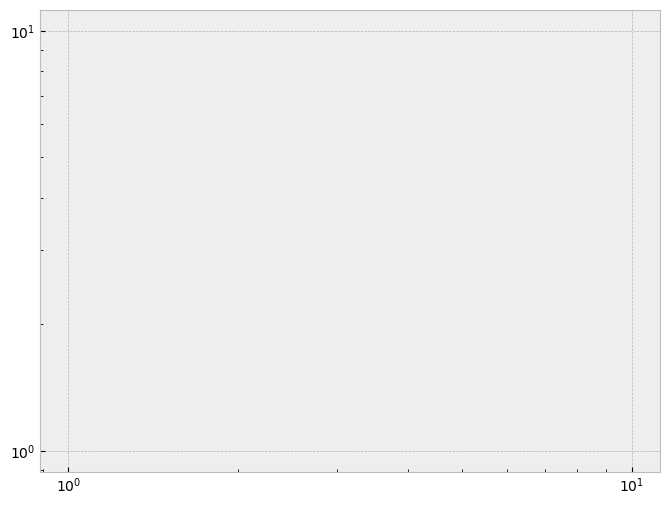

In [ ]:
conversion = 7.4e-40 #----------------------------------------------> CONVERSION GEV4

lw = 1

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.style.use('bmh')

ax.set_xscale('log')
ax.set_yscale('log')

#ax.axvline(1100, c='orange', ls=':', lw=3) # ----------------------------------> Decoupling
#ax.axvline(1.3, c='orange', ls=':', lw=3) # ----------------------------------> Transition matter-dark energy

for index in [4]:
    print(deltas[index])

    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_scf']*conversion, \
                     label=r'$\rho_\phi$', color='k', lw=lw)
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_cdm']*conversion,\
                     label=r'$\rho_{c}$', color='b',lw=lw, ls=':')
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_b']*conversion,\
                     label=r'$\rho_{b}$', color='g',lw=lw, ls='--')
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_g']*conversion, \
                     label=r'$\rho_\gamma$', color='r', lw=lw, ls='-.')
#ax.plot(1.+cosmo_background[index]['z'], (1.+cosmo_background[index]['z'])**2*10**-37, \
                     #label=r'$a^{-2}$', color='k', lw=lw, ls='-.')
    
    my_cosmo = cosmo[index]
    z_eq = int(1/my_cosmo.a_eq()-1.)
    #ax.axvline(z_eq, c='orange', ls=':', lw=2) # ----------------------------------> Matter-radiation equality

    
ax.plot(1.+standard_background['z'], standard_background['(.)rho_scf']*conversion, \
                     label=r'$\rho_\Lambda$', color='k', lw=lw, ls='-')    
    

ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'$\log \,\rho\,\, [\mathrm{GeV}^4]$', labelpad=15, size=25)

ax.set_xlim(1e4,1e2)
ax.set_ylim(1e-47,1e-30)

ax.tick_params(axis='both', which='both', labelsize=15)

for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)

original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

original_labels = ax.get_yticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_yticklabels(labels)
plt.legend(loc='best', frameon=boolean, prop={'size': 20})
#ax.legend(loc='best', frameon=boolean, prop={'size': 25})
fig.tight_layout()
#plt.savefig('cq_dilution.pdf', transparent=True)
plt.show()

0


AttributeError: 'classy.Class' object has no attribute 'a_eq'

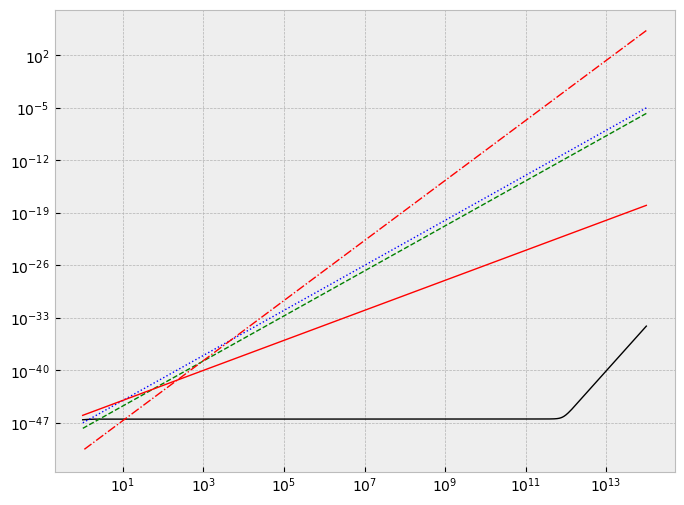

In [ ]:
conversion = 7.4e-40 #----------------------------------------------> CONVERSION GEV4

lw = 1

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.style.use('bmh')

ax.set_xscale('log')
ax.set_yscale('log')

#ax.axvline(1100, c='orange', ls=':', lw=3) # ----------------------------------> Decoupling
#ax.axvline(1.3, c='orange', ls=':', lw=3) # ----------------------------------> Transition matter-dark energy

for index in [1]:
    print(deltas[index])

    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_scf']*conversion, \
                     label=r'$\rho_\phi$', color='k', lw=lw)
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_cdm']*conversion,\
                     label=r'$\rho_{c}$', color='b',lw=lw, ls=':')
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_b']*conversion,\
                     label=r'$\rho_{b}$', color='g',lw=lw, ls='--')
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_g']*conversion, \
                     label=r'$\rho_\gamma$', color='r', lw=lw, ls='-.')
    ax.plot(1.+cosmo_background[index]['z'], (10**-46)*(1.+cosmo_background[index]['z'])**2, \
                     label=r'$\rho_\gamma$', color='r', lw=lw, ls='-')
#ax.plot(1.+cosmo_background[index]['z'], (1.+cosmo_background[index]['z'])**2*10**-37, \
                     #label=r'$a^{-2}$', color='k', lw=lw, ls='-.')
    
    my_cosmo = cosmo[index]
    z_eq = int(1/my_cosmo.a_eq()-1.)
    #ax.axvline(z_eq, c='orange', ls=':', lw=2) # ----------------------------------> Matter-radiation equality

    
ax.plot(1.+standard_background['z'], standard_background['(.)rho_scf']*conversion, \
                     label=r'$\rho_\Lambda$', color='k', lw=lw, ls='-')    
    

ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'$\log \,\rho\,\, [\mathrm{GeV}^4]$', labelpad=15, size=25)

ax.set_xlim(1e14,1)

ax.tick_params(axis='both', which='both', labelsize=15)

for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)

original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

original_labels = ax.get_yticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_yticklabels(labels)
plt.legend(loc='best', frameon=boolean, prop={'size': 20})
#ax.legend(loc='best', frameon=boolean, prop={'size': 25})
fig.tight_layout()
#plt.savefig('cq_dilution.pdf', transparent=True)
plt.show()

0


AttributeError: 'classy.Class' object has no attribute 'a_eq'

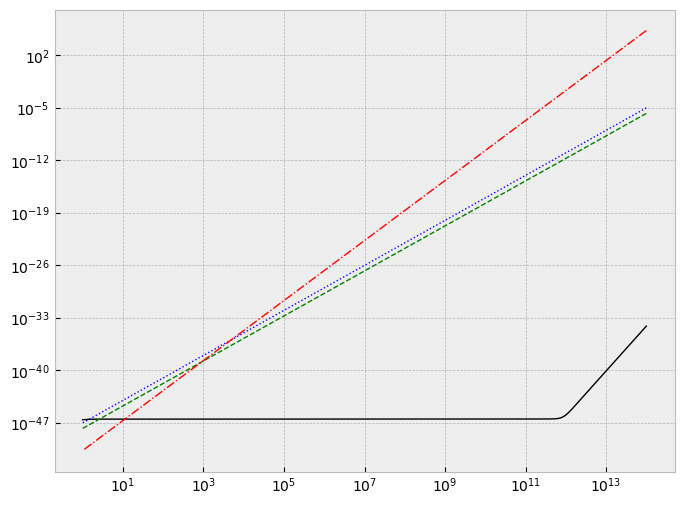

In [ ]:
conversion = 7.4e-40 #----------------------------------------------> CONVERSION GEV4

lw = 1

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.style.use('bmh')

ax.set_xscale('log')
ax.set_yscale('log')

#ax.axvline(1100, c='orange', ls=':', lw=3) # ----------------------------------> Decoupling
#ax.axvline(1.3, c='orange', ls=':', lw=3) # ----------------------------------> Transition matter-dark energy

for index in [2]:
    print(deltas[index])

    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_scf']*conversion, \
                     label=r'$\rho_\phi$', color='k', lw=lw)
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_cdm']*conversion,\
                     label=r'$\rho_{c}$', color='b',lw=lw, ls=':')
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_b']*conversion,\
                     label=r'$\rho_{b}$', color='g',lw=lw, ls='--')
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_g']*conversion, \
                     label=r'$\rho_\gamma$', color='r', lw=lw, ls='-.')
#ax.plot(1.+cosmo_background[index]['z'], (1.+cosmo_background[index]['z'])**2*10**-37, \
                     #label=r'$a^{-2}$', color='k', lw=lw, ls='-.')
    
    my_cosmo = cosmo[index]
    z_eq = int(1/my_cosmo.a_eq()-1.)
    #ax.axvline(z_eq, c='orange', ls=':', lw=2) # ----------------------------------> Matter-radiation equality

    
ax.plot(1.+standard_background['z'], standard_background['(.)rho_scf']*conversion, \
                     label=r'$\rho_\Lambda$', color='k', lw=lw, ls='-')    
    

ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'$\log \,\rho\,\, [\mathrm{GeV}^4]$', labelpad=15, size=25)

ax.set_xlim(1e14,1)

ax.tick_params(axis='both', which='both', labelsize=15)

for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)

original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

original_labels = ax.get_yticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_yticklabels(labels)
plt.legend(loc='best', frameon=boolean, prop={'size': 20})
#ax.legend(loc='best', frameon=boolean, prop={'size': 25})
fig.tight_layout()
#plt.savefig('cq_dilution.pdf', transparent=True)
plt.show()

IndexError: list index out of range

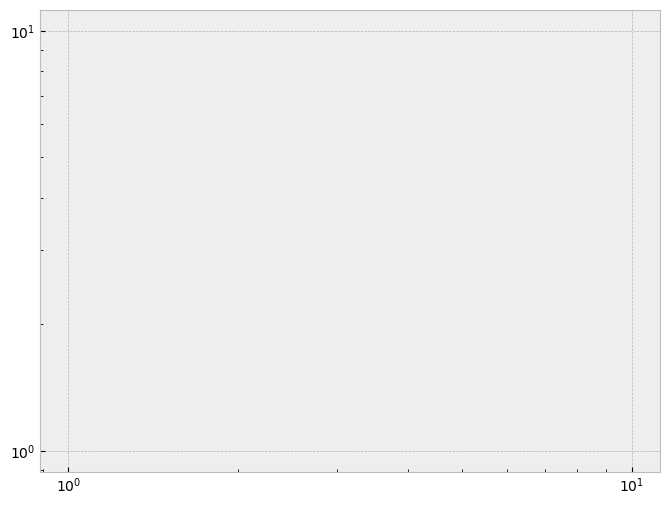

In [ ]:
conversion = 7.4e-40 #----------------------------------------------> CONVERSION GEV4

lw = 1

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.style.use('bmh')

ax.set_xscale('log')
ax.set_yscale('log')

#ax.axvline(1100, c='orange', ls=':', lw=3) # ----------------------------------> Decoupling
#ax.axvline(1.3, c='orange', ls=':', lw=3) # ----------------------------------> Transition matter-dark energy

for index in [3]:
    print(deltas[index])

    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_scf']*conversion, \
                     label=r'$\rho_\phi$', color='k', lw=lw)
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_cdm']*conversion,\
                     label=r'$\rho_{c}$', color='b',lw=lw, ls=':')
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_b']*conversion,\
                     label=r'$\rho_{b}$', color='g',lw=lw, ls='--')
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_g']*conversion, \
                     label=r'$\rho_\gamma$', color='r', lw=lw, ls='-.')
#ax.plot(1.+cosmo_background[index]['z'], (1.+cosmo_background[index]['z'])**2*10**-37, \
                     #label=r'$a^{-2}$', color='k', lw=lw, ls='-.')
    
    my_cosmo = cosmo[index]
    z_eq = int(1/my_cosmo.a_eq()-1.)
    #ax.axvline(z_eq, c='orange', ls=':', lw=2) # ----------------------------------> Matter-radiation equality

    
ax.plot(1.+standard_background['z'], standard_background['(.)rho_scf']*conversion, \
                     label=r'$\rho_\Lambda$', color='k', lw=lw, ls='-')    
    

ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'$\log \,\rho\,\, [\mathrm{GeV}^4]$', labelpad=15, size=25)

ax.set_xlim(1e14,1)

ax.tick_params(axis='both', which='both', labelsize=15)

for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)

original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

original_labels = ax.get_yticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_yticklabels(labels)
plt.legend(loc='best', frameon=boolean, prop={'size': 20})
#ax.legend(loc='best', frameon=boolean, prop={'size': 25})
fig.tight_layout()
#plt.savefig('cq_dilution.pdf', transparent=True)
plt.show()

IndexError: list index out of range

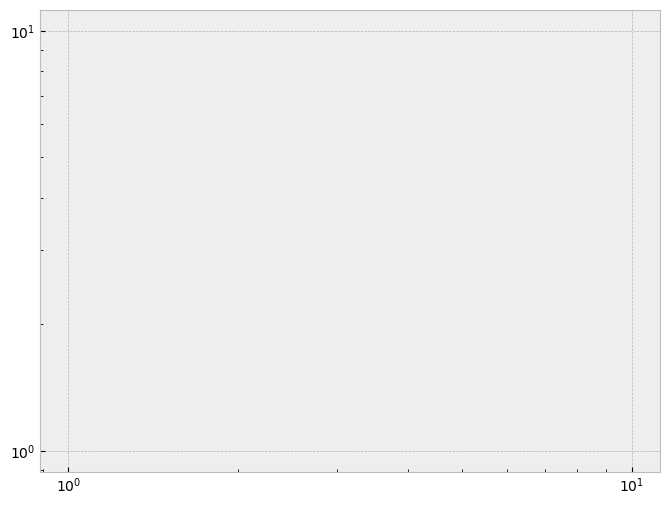

In [ ]:
conversion = 7.4e-40 #----------------------------------------------> CONVERSION GEV4

lw = 1

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.style.use('bmh')

ax.set_xscale('log')
ax.set_yscale('log')

#ax.axvline(1100, c='orange', ls=':', lw=3) # ----------------------------------> Decoupling
#ax.axvline(1.3, c='orange', ls=':', lw=3) # ----------------------------------> Transition matter-dark energy

for index in [4]:
    print(deltas[index])

    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_scf']*conversion, \
                     label=r'$\rho_\phi$', color='k', lw=lw)
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_cdm']*conversion,\
                     label=r'$\rho_{c}$', color='b',lw=lw, ls=':')
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_b']*conversion,\
                     label=r'$\rho_{b}$', color='g',lw=lw, ls='--')
    ax.plot(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_g']*conversion, \
                     label=r'$\rho_\gamma$', color='r', lw=lw, ls='-.')
#ax.plot(1.+cosmo_background[index]['z'], (1.+cosmo_background[index]['z'])**2*10**-37, \
                     #label=r'$a^{-2}$', color='k', lw=lw, ls='-.')
    
    my_cosmo = cosmo[index]
    z_eq = int(1/my_cosmo.a_eq()-1.)
    #ax.axvline(z_eq, c='orange', ls=':', lw=2) # ----------------------------------> Matter-radiation equality

    
ax.plot(1.+standard_background['z'], standard_background['(.)rho_scf']*conversion, \
                     label=r'$\rho_\Lambda$', color='k', lw=lw, ls='-')    
    

ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'$\log \,\rho\,\, [\mathrm{GeV}^4]$', labelpad=15, size=25)

ax.set_xlim(1e14,1)

ax.tick_params(axis='both', which='both', labelsize=15)

for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)

original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

original_labels = ax.get_yticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_yticklabels(labels)
plt.legend(loc='best', frameon=boolean, prop={'size': 20})
#ax.legend(loc='best', frameon=boolean, prop={'size': 25})
fig.tight_layout()
#plt.savefig('cq_dilution.pdf', transparent=True)
plt.show()

In [ ]:
plt.style.use('bmh')

lw = 1
ls = ['-',(0,(5,1)),'--', '-.', ':']
#color = ['navy','r', 'b','g']
color = ['r','g','y','b','navy']

fig, ax = plt.subplots(1, 1, figsize=(8,6))

i=0
for index in [0,1,2,3]:
    print(cosmo_background[index]['(.)p_scf'][-1]/cosmo_background[index]['(.)rho_scf'][-1])
    ax.plot(1.+cosmo_background[index]['z'], \
            cosmo_background[index]['(.)p_scf'] / cosmo_background[index]['(.)rho_scf'], \
            label = r'$\delta_s =  $'+str(deltas[index]),lw=lw,ls=ls[i],c=color[i])
    i+=1

ax.set_xscale('log')
original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

ax.set_xlim(1e2, 1)
ax.set_ylim(-1.05,1.05)

ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'$w_\phi$', size=25)

ax.axhline(-1, c='black', ls='-', lw=1.,label = r'$\Lambda$CDM') # -----> phi'_i

#ax.set_yticks([i for i in np.linspace(-1,0.1,11)])

ax.tick_params(axis='both', which='both', labelsize=20)
for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)
    
#ax.set_yticks([i for i in np.linspace(-1,1,9)])

plt.legend(loc='best', frameon=boolean, prop={'size': 20})
fig.tight_layout()
plt.show()

KeyError: 'Q_scf'

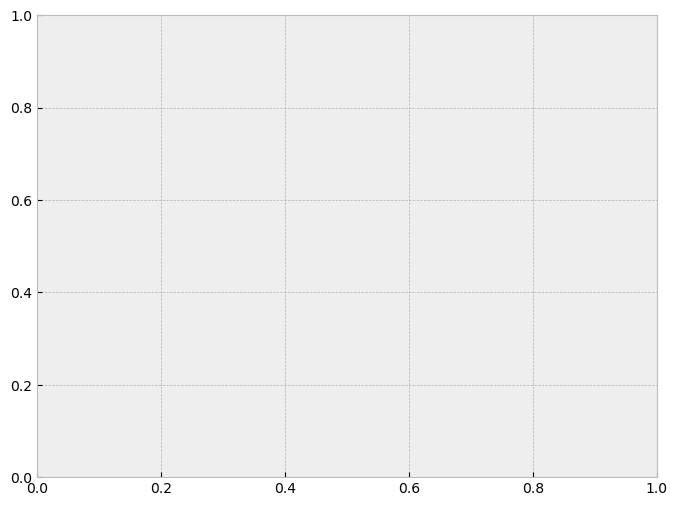

In [ ]:
plt.style.use('bmh')

lw = 1
ls = ['-',(0,(5,1)),'--', '-.', ':']
#color = ['navy','r', 'b','g']
color = ['r','g','y','b','navy']

fig, ax = plt.subplots(1, 1, figsize=(8,6))

i=0
for index in [0,1,2,3]:
    print(- cosmo_background[index]['Q_scf'][-1] / (3.*cosmo_background[index]['(.)rho_cdm'][-1]))
    ax.plot(1.+cosmo_background[index]['z'], \
            - cosmo_background[index]['Q_scf'] / (3.*cosmo_background[index]['(.)rho_cdm']), \
            label = r'$\delta_s =  $'+str(deltas[index]),lw=lw,ls=ls[i],c=color[i])
    i+=1

ax.set_xscale('log')
original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

ax.set_xlim(1e5, 1)
ax.set_ylim(0.,0.5)

ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'$\beta$', size=25)

ax.axhline(0, c='black', ls='-', lw=1.,label = r'$\Lambda$CDM') # -----> phi'_i

#ax.set_yticks([i for i in np.linspace(-1,0.1,11)])

ax.tick_params(axis='both', which='both', labelsize=20)
for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)
    
#ax.set_yticks([i for i in np.linspace(-1,1,9)])

plt.legend(loc='best', frameon=boolean, prop={'size': 20})
fig.tight_layout()
plt.show()

In [ ]:
plt.style.use('bmh')

lw = 1
ls = ['-',(0,(5,1)),'--', '-.', ':']
#color = ['navy','r', 'b','g']
color = ['r','g','y','b','navy']

fig, ax = plt.subplots(1, 1, figsize=(8,6))

i=0
for index in [0,1,2,3]:
    print(2* (cosmo_background[index]['Q_scf'][-1] / (3.*cosmo_background[index]['(.)rho_cdm'][-1]))**2)
    ax.plot(1.+cosmo_background[index]['z'], \
            2* (cosmo_background[index]['Q_scf'] / (3.*cosmo_background[index]['(.)rho_cdm']))**2, \
            label = r'$\delta_s =  $'+str(deltas[index]),lw=lw,ls=ls[i],c=color[i])
    i+=1

ax.set_xscale('log')
original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

ax.set_xlim(1e5, 1)
ax.set_ylim(0.,0.06)

ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'$G_{\rm eff}/G -1$', size=25)

ax.axhline(0, c='black', ls='-', lw=1.,label = r'$\Lambda$CDM') # -----> phi'_i

#ax.set_yticks([i for i in np.linspace(-1,0.1,11)])

ax.tick_params(axis='both', which='both', labelsize=20)
for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)
    
#ax.set_yticks([i for i in np.linspace(-1,1,9)])

plt.legend(loc='best', frameon=boolean, prop={'size': 20})
fig.tight_layout()
plt.show()

In [ ]:
plt.style.use('bmh')

ls = ['-','-.',':'] # ---------------------------------------------------------> line style
lw = 1 # ----------------------------------------------------------------------> line thickness

print(z_eq)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
ax.set_xscale('log') # --------------------------------------------------------> log scale of the x-axis

ax.axvline(z_eq, c='orange', ls=':', lw=lw) # ----------------------------------> Radiation-matter equality
#ax.axvline(1100, c='orange', ls=':', lw=3) # ----------------------------------> Decoupling
#ax.axvline(1.3, c='orange', ls=':', lw=3) # ----------------------------------> Transition matter-dark energy

i=0
for index in [0,2,4]:
    ax.plot(1.+cosmo_background[index]['z'], \
            cosmo_background[index]['(.)rho_scf'] / cosmo_background[index]['(.)rho_crit'],\
            label = r'$\Omega_\phi$'+'  '+ \
            r'$\delta_s =  $'+str(deltas[index]), lw=lw, ls=ls[i], c='k')
    
    ax.plot(1.+cosmo_background[index]['z'], \
            (cosmo_background[index]['(.)rho_cdm']+cosmo_background[index]['(.)rho_b'])/ \
            cosmo_background[index]['(.)rho_crit'],\
            label = r'$\Omega_m$', lw=lw, ls=ls[i], c='b')
    
    ax.plot(1.+cosmo_background[index]['z'], \
            (cosmo_background[index]['(.)rho_g']+cosmo_background[index]['(.)rho_ur']) / \
            cosmo_background[index]['(.)rho_crit'],\
            label = r'$\Omega_r$', lw=lw, ls=ls[i], c='r')
    
    i+=1

original_labels = ax.get_xticks() #-----------------------------------------------> change xticks labels
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

#---------------------------------------------------------------------------------> change limits
ax.set_xlim(1,1e6)
ax.set_ylim(-0.05, 1.05)

#---------------------------------------------------------------------------------> change ticklabels distance
ax.tick_params(axis='both', which='both', labelsize=20)
for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)

ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'$\Omega$', size=25)

plt.legend(loc='best', frameon=boolean, prop={'size': 15})
fig.tight_layout()
plt.show()

In [ ]:
plt.style.use('bmh')

ls = ['-','-.',':'] # ---------------------------------------------------------> line style
lw = 1 # ----------------------------------------------------------------------> line thickness

print(z_eq)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
ax.set_xscale('log') # --------------------------------------------------------> log scale of the x-axis

ax.axvline(z_eq, c='orange', ls=':', lw=lw) # ----------------------------------> Radiation-matter equality
#ax.axvline(1100, c='orange', ls=':', lw=3) # ----------------------------------> Decoupling
#ax.axvline(1.3, c='orange', ls=':', lw=3) # ----------------------------------> Transition matter-dark energy

i=0
for index in [0,2,4]:
    ax.plot(1.+cosmo_background[index]['z'], \
            cosmo_background[index]['(.)rho_scf'] / cosmo_background[index]['(.)rho_crit'],\
            label = r'$\Omega_\phi$'+'  '+ \
            r'$\delta_s =  $'+str(deltas[index]), lw=lw, ls=ls[i], c='k')
    
    ax.plot(1.+cosmo_background[index]['z'], \
            (cosmo_background[index]['(.)rho_cdm']+cosmo_background[index]['(.)rho_b'])/ \
            cosmo_background[index]['(.)rho_crit'],\
            label = r'$\Omega_m$', lw=lw, ls=ls[i], c='b')
    
    ax.plot(1.+cosmo_background[index]['z'], \
            (cosmo_background[index]['(.)rho_g']+cosmo_background[index]['(.)rho_ur']) / \
            cosmo_background[index]['(.)rho_crit'],\
            label = r'$\Omega_r$', lw=lw, ls=ls[i], c='r')
    
    i+=1

original_labels = ax.get_xticks() #-----------------------------------------------> change xticks labels
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)

#---------------------------------------------------------------------------------> change limits
ax.set_xlim(1,1e1)
ax.set_ylim(-0.05, 1.05)

#---------------------------------------------------------------------------------> change ticklabels distance
ax.tick_params(axis='both', which='both', labelsize=20)
for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)

ax.set_xlabel(r'$\log(1+z)$', size=25)
ax.set_ylabel(r'$\Omega$', size=25)

plt.legend(loc='best', frameon=boolean, prop={'size': 15})
fig.tight_layout()
plt.show()

k = 0.084445


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_20507/4263390279.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([-1,0,1,2,3])


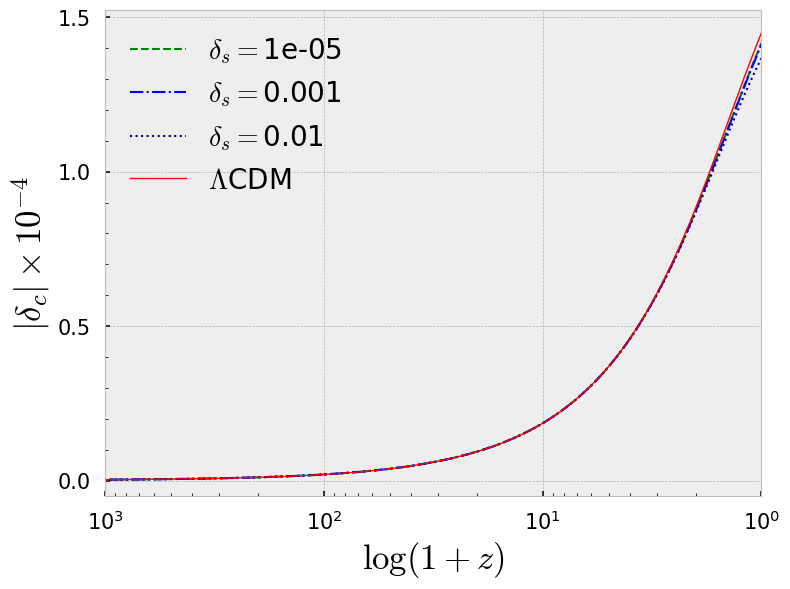

-1.3678590890601934


In [ ]:
index_k_list = [0]
label = [r'$|\delta_c|\times10^{-4}$','','','']

lw = 1.5
ls = ['--', '-.', ':']
color = ['g','b','navy']

plt.style.use('bmh')

fig, ax = plt.subplots(1, 1, figsize=(8,6))

for i in [0]: #--------------------------------------------> values of k-scales
    index_k = index_k_list[i]
    print('k =', k_scale[index_k])
    style=0
    for index in [0,1,2]: #--------------------------------------------> values of beta
        cosmoPerturb=cosmo[index].get_perturbations()
        a = cosmoPerturb['scalar'][index_k]['a']
        z=1/a-1
        delta_cdm = cosmoPerturb['scalar'][index_k]['delta_cdm']
    
        ax.plot(1+z, np.abs(delta_cdm)*1e-4, \
             label = r'$\delta_s =  $'+str(deltas[index]),lw=lw, ls=ls[style],c=color[style])
        style+=1

    standardPerturb=standard.get_perturbations()
    a = standardPerturb['scalar'][index_k]['a']
    z=1/a-1
    delta_cdm = standardPerturb['scalar'][index_k]['delta_cdm']

    ax.plot(1+z, np.abs(delta_cdm)*1e-4, c='r', ls='-', label = r'$\Lambda$CDM',lw=1)

    ax.set_xticklabels([-1,0,1,2,3])

    ax.set_ylabel(label[i], size=25)
    ax.set_xlabel(r'$\log(1+z)$', size=25)
    ax.set_xlim(1e3,1)
    ax.set_ylim(-0.05)
    #ax.set_title('k = '+str(k_scale[index_k]), size=20)
    ax.tick_params(axis='both', which='major', labelsize=15, width=1.1)
    for tick in ax.xaxis.get_major_ticks():
        tick.set_pad(10)
    for tick in ax.yaxis.get_major_ticks():
        tick.set_pad(10)    

#ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True) #---------------------------> Scientific format
#ax.yaxis.offsetText.set_fontsize(20) #---------------------------> size of the scientific format

    
ax.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax.locator_params(nbins=5,axis='y')
ax.locator_params(nbins=5,axis='x')
ax.set_xscale('log')

ax.legend(loc='best', frameon=boolean, prop={'size': 20})

fig.tight_layout()

plt.show()

print(cosmoPerturb['scalar'][index_k]['delta_cdm'][-1]*1e-4)

k = 0.084445


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_20507/4094805165.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([-1,0,1,2,3])


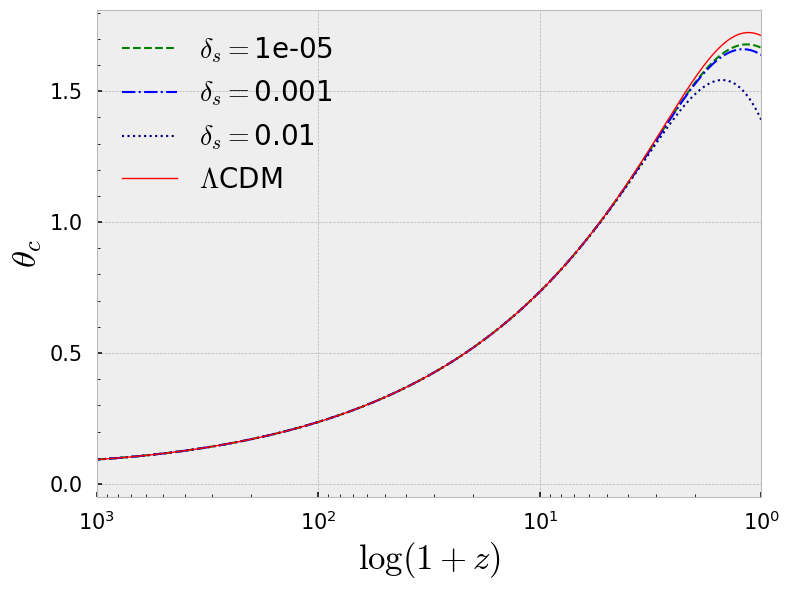

theta_cdm at z=0 ----> 1.389290185401702


In [ ]:
index_k_list = [0]
label = [r'$\theta_c$','','','']

lw = 1.5
ls = ['--', '-.', ':']
color = ['g','b','navy']

plt.style.use('bmh')

fig, ax = plt.subplots(1, 1, figsize=(8,6))

for i in [0]: #--------------------------------------------> values of k-scales
    index_k = index_k_list[i]
    print('k =', k_scale[index_k])
    style=0
    for index in [0,1,2]: #--------------------------------------------> values of beta
        cosmoPerturb=cosmo[index].get_perturbations()
        a = cosmoPerturb['scalar'][index_k]['a']
        z=1/a-1
        theta_cdm = cosmoPerturb['scalar'][index_k]['theta_cdm']
    
        ax.plot(1+z, theta_cdm, \
             label = r'$\delta_s =  $'+str(deltas[index]),lw=lw, ls=ls[style],c=color[style])
        style+=1

    standardPerturb=standard.get_perturbations()
    a = standardPerturb['scalar'][index_k]['a']
    z=1/a-1
    theta_cdm = standardPerturb['scalar'][index_k]['theta_cdm']

    ax.plot(1+z, theta_cdm, c='r', ls='-', label = r'$\Lambda$CDM',lw=1)

    ax.set_xticklabels([-1,0,1,2,3])

    ax.set_ylabel(label[i], size=25)
    ax.set_xlabel(r'$\log(1+z)$', size=25)
    ax.set_xlim(1e3,1)
    ax.set_ylim(-0.05)
    #ax.set_title('k = '+str(k_scale[index_k]), size=20)
    ax.tick_params(axis='both', which='major', labelsize=15, width=1.1)
    for tick in ax.xaxis.get_major_ticks():
        tick.set_pad(10)
    for tick in ax.yaxis.get_major_ticks():
        tick.set_pad(10)    

#ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True) #---------------------------> Scientific format
#ax.yaxis.offsetText.set_fontsize(20) #---------------------------> size of the scientific format

    
ax.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax.locator_params(axis='y', nbins=5)
ax.locator_params(axis='x', nbins=5)
ax.set_xscale('log')


ax.legend(loc='best', frameon=boolean, prop={'size': 20})

fig.tight_layout()

plt.show()
print('theta_cdm at z=0 ---->', cosmoPerturb['scalar'][index_k]['theta_cdm'][-1])

In [ ]:
idx = 0
k0=k_scale[0]
print(k0)
dz = 0.01
hstep=0.001
#Make a mock array; this will contain the redshifts z\in[0,5,0.01] we need for the interpolation
zed = np.arange(0.0, 5.0,dz)
#Make a mock array; this will contain f(k,z) at z\in[0,5]
scale_growthf=np.arange(0.0, 5.0,dz)
#Make a mock array; this will contain P(k,z) at z\in[0,2]
Pkz=np.arange(0.0,5.0,dz)
growths8=np.arange(0.0,5.0,dz)
s8 = my_cosmo.sigma8()
print(s8)
delta_mtot_prime=np.arange(0.0,5.0,dz)
delta_mtot=np.arange(0.0,5.0,dz)
hb=np.arange(0.0,5.0,dz)

cosmoPerturb=cosmo[idx].get_perturbations()
delta_mtot0 = cosmoPerturb['scalar'][0]['delta_mtot'][-1]
print(delta_mtot0)

# Get the P(k,z) from CLASS and interpolate
for zz in range(len(zed)):
    Pkz[zz]=my_cosmo.pk(k0,zed[zz])
    Pkint=interp1d(zed,Pkz,kind='cubic')
    delta_mtot_prime[zz]= cosmoPerturb['scalar'][0]['delta_mtot_prime'][zz]
    delta_mtot_primeint=interp1d(zed,delta_mtot_prime,kind='cubic')
    delta_mtot[zz]= cosmoPerturb['scalar'][0]['delta_mtot'][zz]
    delta_mtotint=interp1d(zed,delta_mtot,kind='cubic')
    hb[zz] = cosmo_background[index]['H [1/Mpc]'][zz]
    hbint=interp1d(zed,hb,kind='cubic')
    
# Calculate the growth via f=-0.5*(1+z)*D[Log[P(k,z),z] with a simple difference and interpolate
for zz in range(len(zed)-1):
# One point numerical derivative (forward difference)
    scale_growthf[zz]=-0.5*(1+zed[zz])*(Pkint(zed[zz]+hstep)-Pkint(zed[zz]))/hstep/Pkint(zed[zz])
    growths8[zz]=(s8/delta_mtot0)*(delta_mtotint[zed[zz]]/(hbint[zed[zz]]*(1/(1+zed[zz]))))
    scale_growthfint=interp1d(zed,scale_growthf,kind='cubic')
    growths8int=interp1d(zed,growths8,kind='cubic')

0.084445
0.8293566190644832


KeyError: 'delta_mtot'

NameError: name 'my_cosmo' is not defined

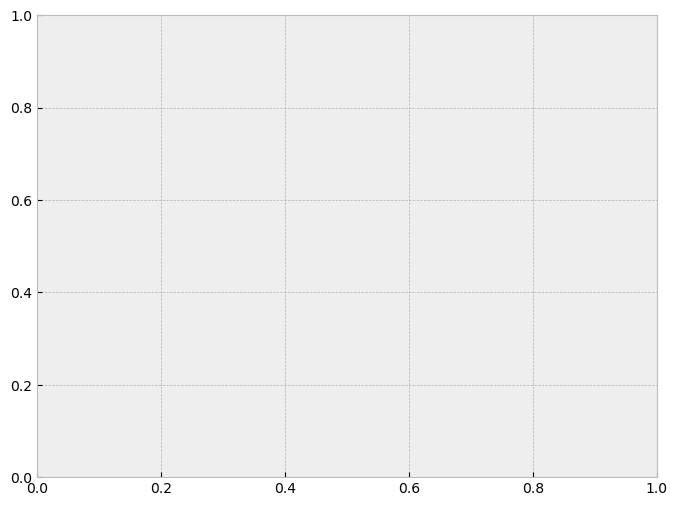

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.style.use('bmh')
idx=0

zv = []
fv = []
fvInt = []

for z in cosmo_background[idx]['z']:
    if z <4:
        zv.append(z)
        fv.append(my_cosmo.scale_independent_growth_factor_f(z))
        fvInt.append(scale_growthfint(z))
        #print z, my_cosmo.scale_independent_growth_factor_f(z), scale_growthfint(z)

ax.plot(zv, fv, label='Class')
ax.plot(zv, fvInt, label='Interpolated')

ax.set_xlim(5.,0.)
ax.set_ylim(-0.05,1.05)
ax.set_xlabel(r'$z$', size=25)
ax.set_ylabel(r'$f$', labelpad=15, size=25)
plt.legend(frameon=boolean)
plt.show()

0.8293566190644832


NameError: name 'scale_growthfint' is not defined

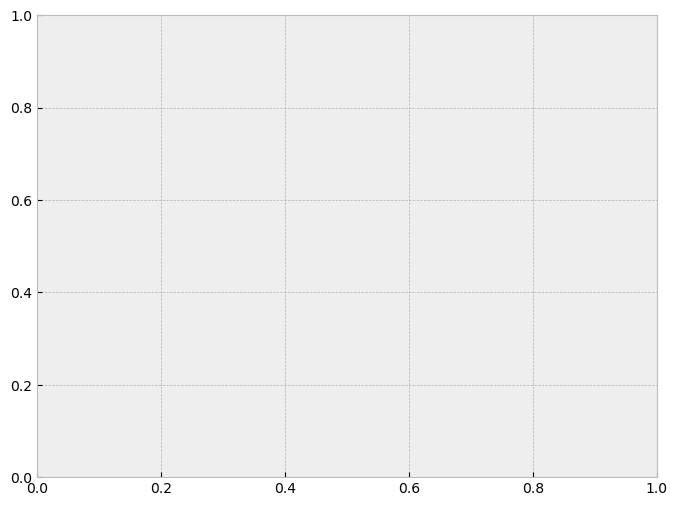

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.style.use('bmh')
idx=0
my_cosmo = cosmo[idx]
print(my_cosmo.sigma8())

zv = []
fv = []
fvInt = []
fsInt = []

#print(standard.sigma(8/standard.h(),0))


for z in cosmo_background[idx]['z']:
    if z <4:
        zv.append(z)
        fv.append(my_cosmo.scale_independent_growth_factor_f(z))
        fvInt.append(scale_growthfint(z))
        fsInt.append(scale_growths8int(z))
        #print z, my_cosmo.scale_independent_growth_factor_f(z), scale_growthfint(z)

#ax.plot(zv, fv*my_cosmo.sigma8(), label='Class')
ax.plot(zv, fsInt, label='Interpolated')

ax.set_xlim(2.,0.)
ax.set_ylim(-0.05,1.05)
ax.set_xlabel(r'$z$', size=25)
ax.set_ylabel(r'$f \sigma_8$', labelpad=15, size=25)
plt.legend(frameon=boolean)
plt.show()

In [ ]:
index_k_list = [0]
label = [r'$f \sigma_8$','','','']

delta_mtot_k2p_int_lcdm(aaa)/(hb_lcdm_int(aaa)*(1./(aaa))))*(0.8102/delta_mtot_k2_intt_lcdm(1))

lw = 1.5
ls = ['--', '-.', ':']
color = ['g','b','navy']

plt.style.use('bmh')

fig, ax = plt.subplots(1, 1, figsize=(8,6))

for i in [0]: #--------------------------------------------> values of k-scales
    index_k = index_k_list[i]
    print('k =', k_scale[index_k])
    style=0
    for index in [0,1,2]: #--------------------------------------------> values of beta
        cosmoPerturb=cosmo[index].get_perturbations()
        a = cosmoPerturb['scalar'][index_k]['a']
        z=1/a-1
        theta_cdm = cosmoPerturb['scalar'][index_k]['theta_cdm']
    
        ax.plot(1+z, theta_cdm, \
             label = r'$\delta_s =  $'+str(deltas[index]),lw=lw, ls=ls[style],c=color[style])
        style+=1

    standardPerturb=standard.get_perturbations()
    a = standardPerturb['scalar'][index_k]['a']
    z=1/a-1
    f_growth = standardPerturb['scalar'][index_k]['theta_cdm']

    ax.plot(1+z, theta_cdm, c='r', ls='-', label = r'$\Lambda$CDM',lw=1)

    ax.set_xticklabels([-1,0,1,2,3])

    ax.set_ylabel(label[i], size=25)
    ax.set_xlabel(r'$\log(1+z)$', size=25)
    ax.set_xlim(1e3,1)
    ax.set_ylim(-0.05)
    #ax.set_title('k = '+str(k_scale[index_k]), size=20)
    ax.tick_params(axis='both', which='major', labelsize=15, width=1.1)
    for tick in ax.xaxis.get_major_ticks():
        tick.set_pad(10)
    for tick in ax.yaxis.get_major_ticks():
        tick.set_pad(10)    

#ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True) #---------------------------> Scientific format
#ax.yaxis.offsetText.set_fontsize(20) #---------------------------> size of the scientific format

    
ax.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax.locator_params(axis='y', nbins=5)
ax.locator_params(axis='x', nbins=5)
ax.set_xscale('log')


ax.legend(loc='best', frameon=boolean, prop={'size': 20})

fig.tight_layout()

plt.show()
print('theta_cdm at z=0 ---->', cosmoPerturb['scalar'][index_k]['theta_cdm'][-1])

SyntaxError: unmatched ')' (4117316140.py, line 4)

/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_23705/3864843908.py:38: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax0.plot(kk,Pk_standard,'r', label = r'$\Lambda$CDM', c = 'r', ls='-', lw=1)


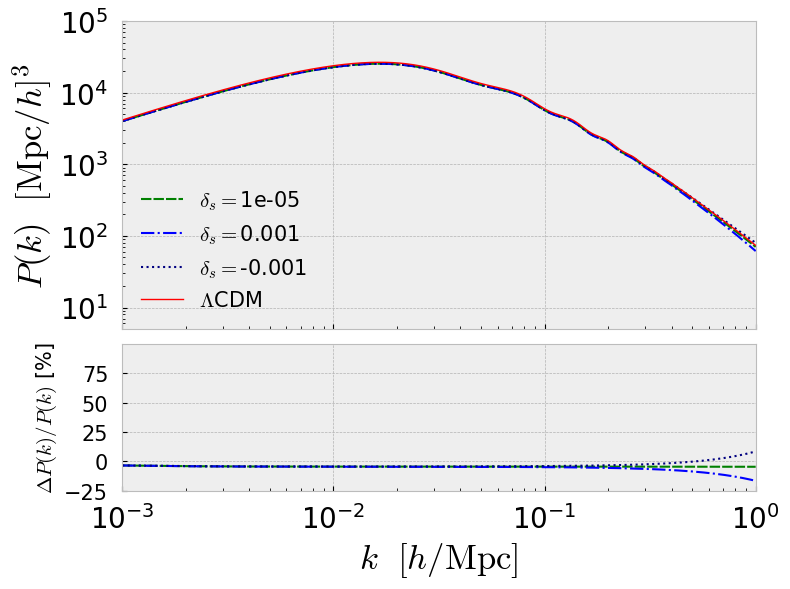

In [26]:
plt.style.use('bmh')

lw = 1.5
ls = [(0,(5,1)), '-.', ':']
color = ['g','b','navy']

fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1)

plt.subplots_adjust(hspace=0.)

kk = np.logspace(-3,np.log10(1),10000) # k in h/Mpc

Pk_standard = [] # P(k) in (Mpc/h)**3
h_standard = standard.h() # get reduced Hubble for conversions to 1/Mpc
for k in kk:
    Pk_standard.append(standard.pk(k*h_standard,0.)*h_standard**3) # function .pk(k,z)

    
i=0

for index in [0,1,2]:
    Pk = [] # P(k) in (Mpc/h)**3
    h = cosmo[index].h() # get reduced Hubble for conversions to 1/Mpc
    DELTA = []
    for k in kk:
        Pk.append(cosmo[index].pk(k*h,0.)*h**3) # function .pk(k,z)
        DELTA.append(100*(cosmo[index].pk(k*h,0.)*h**3 - standard.pk(k*h_standard,0.)*h_standard**3)\
        /(standard.pk(k*h_standard,0.)*h_standard**3))
    # plot P(k)
    ax0.plot(kk,Pk, label = \
                 r'$\delta_s =  $'+str(deltas[index]), lw=lw, ls=ls[i], c=color[i])
    ax1.plot(kk,DELTA, label = \
                 r'$\delta_s =  $'+str(deltas[index]), lw=lw, ls=ls[i], c=color[i])
    i+=1

ax0.plot(kk,Pk_standard,'r', label = r'$\Lambda$CDM', c = 'r', ls='-', lw=1)
    
ax0.set_xscale('log');ax0.set_yscale('log');ax0.set_xlim(kk[0],kk[-1]);ax0.set_ylim(5,1e5)
ax1.set_xscale('log');ax1.set_yscale('linear');ax1.set_xlim(kk[0],kk[-1]);

ax1.set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=25)
ax0.set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=25)
ax1.set_ylabel(r'$\Delta P(k)/P(k)$'+' [%]', size=15)

ax1.set_ylim(-25,100)
ax1.set_yticks([i for i in np.linspace(-25,75,5)])

ax0.tick_params(axis='y', which='both', labelsize=20)
ax0.tick_params(axis='x', which='both', labelbottom=False)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='y', which='both', labelsize=15)
ax1.tick_params(axis='x', which='both', labelsize=20)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(10)

ax0.legend(loc='best', frameon=boolean, prop={'size': 15})

plt.tight_layout()
#plt.savefig('cq_linear_power_spectrum.pdf', transparent=True)

plt.show()

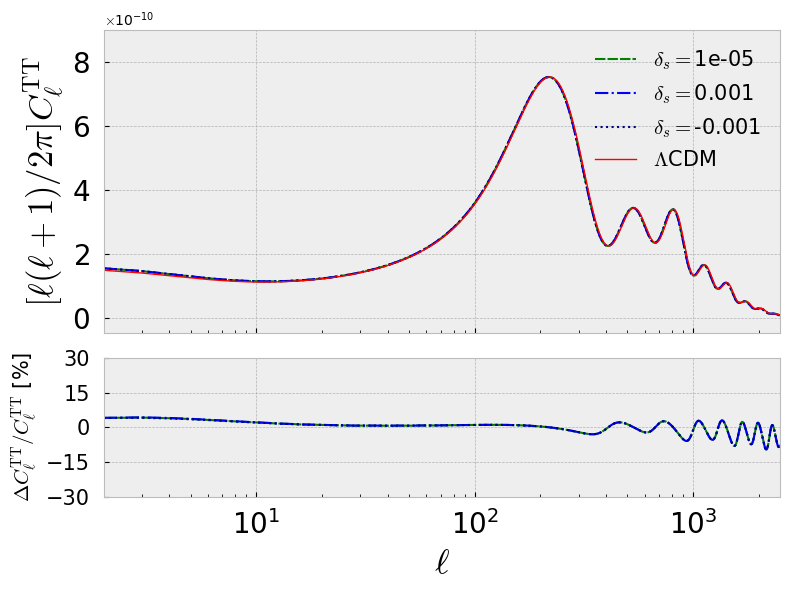

In [20]:
plt.style.use('bmh')

lw = 1.5
ls = [(0,(5,1)), '-.', ':']
color = ['g','b','navy']

fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1)

plt.subplots_adjust(hspace=0.)

# get lambdaCDM
cls_standard = standard.raw_cl(2500)
ll = cls_standard['ell'][2:]
clTT_standard = cls_standard['tt'][2:]

i=0
for index in [0,1,2]: #--------------------------------> BETA
# get all C_l output
    cls = cosmo[index].raw_cl(2500)
    ll = cls['ell'][2:]
    clTT = cls['tt'][2:]
# plot C_l^TT
    ax0.plot(ll,clTT*ll*(ll+1)/2./np.pi, label = \
             r'$\delta_s =  $'+str(deltas[index]),lw=lw, ls=ls[i], c=color[i])
    DELTA = (clTT  - clTT_standard) / clTT_standard
    ax1.plot(ll,DELTA*100, lw=lw, ls=ls[i], c=color[i])
    i+=1
    
# plot LCDM
ax0.plot(ll,clTT_standard*ll*(ll+1)/2./np.pi, label = r'$\Lambda$CDM', c = 'r', ls='-',lw=1)

ax0.set_xscale('log');ax0.set_yscale('linear');ax0.set_xlim(2,2500);ax0.set_ylim(-5*9e-12,9e-10)
ax1.set_xscale('log');ax1.set_yscale('linear');ax1.set_xlim(2,2500)
ax1.set_ylim(-30,30)
ax1.set_yticks([i for i in np.linspace(-30,30,5)])
ax1.set_xlabel(r'$\ell$', size=25)
ax0.set_ylabel(r'$[\ell(\ell+1)/2\pi]  C_\ell^\mathrm{TT}$', size=25)
ax1.set_ylabel(r'$\Delta C_\ell^\mathrm{TT}/C_\ell^\mathrm{TT}$'+' [%]', size=15)

#ax1.set_yticks([i for i in np.linspace(0,40,5)])

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='y', which='both', labelsize=20)
ax0.tick_params(axis='x', which='both', labelbottom=False)

ax1.tick_params(axis='y', which='both', labelsize=15)
ax1.tick_params(axis='x', which='both', labelsize=20)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(10)

ax0.legend(loc='best', frameon=boolean, prop={'size': 15})

plt.tight_layout()
#plt.savefig('cq_cmb_tt.pdf', transparent=True)

plt.show()

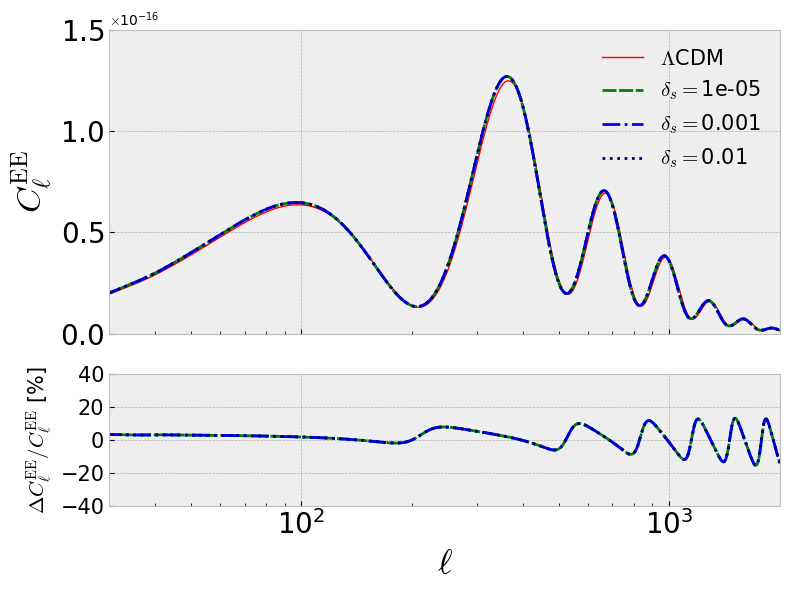

In [ ]:
plt.style.use('bmh')

lw = 2
ls = [(0,(5,1)), '-.', ':']
color = ['g','b','navy']

fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1)

plt.subplots_adjust(hspace=0.)

# get lambdaCDM
cls_standard = standard.raw_cl(2000)
ll = cls_standard['ell'][2:]
clEE_standard = cls_standard['ee'][2:]
# plot LCDM
ax0.plot(ll,clEE_standard, label = r'$\Lambda$CDM', c = 'r', ls='-',lw=1)

i=0
for index in [0,1,2]: #--------------------------------> BETA
# get all C_l output
    cls = cosmo[index].raw_cl(2000)
    ll = cls['ell'][2:]
    clEE = cls['ee'][2:]
# plot C_l^EE
    ax0.plot(ll,clEE, label = \
             r'$\delta_s =  $'+str(deltas[index]),lw=lw, ls=ls[i], c=color[i])
    DELTA = (clEE  - clEE_standard) / clEE_standard
    ax1.plot(ll,DELTA*100, lw=lw, ls=ls[i], c=color[i])
    i+=1

ax0.set_xscale('log')
ax0.set_yscale('linear')
ax0.set_xlim(30,2000)
ax0.set_ylim(0,1.5e-16)

ax1.set_xscale('log')
ax1.set_yscale('linear')
ax1.set_xlim(30,2000)
ax1.set_ylim(-40.,40.)
ax1.set_yticks([i for i in np.linspace(-40,40,5)])

ax1.set_xlabel(r'$\ell$', size=25)
ax0.set_ylabel(r'$C_\ell^\mathrm{EE}$', size=25)
ax1.set_ylabel(r'$\Delta C_\ell^\mathrm{EE}/C_\ell^\mathrm{EE}$'+' [%]', size=15)

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='y', which='both', labelsize=20)
ax0.tick_params(axis='x', which='both', labelbottom=False)

ax1.tick_params(axis='y', which='both', labelsize=15)
ax1.tick_params(axis='x', which='both', labelsize=20)

ax0.legend(loc='best', frameon=boolean, prop={'size': 15})

plt.tight_layout()

#plt.savefig('cq_cmb_highl_ee.pdf', transparent=True)
plt.show()

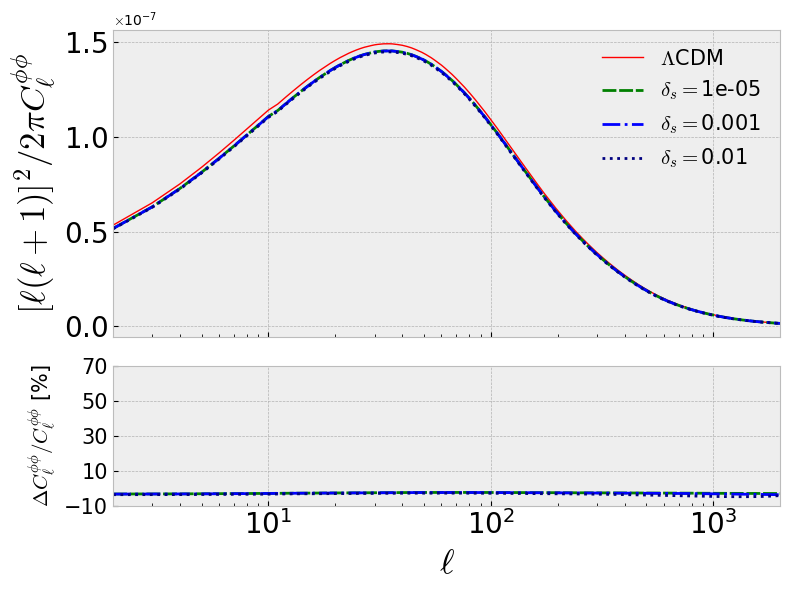

In [ ]:
plt.style.use('bmh')

lw = 2
ls = [(0,(5,1)), '-.', ':']
color = ['g','b','navy']

fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1)

plt.subplots_adjust(hspace=0.)

# get lambdaCDM
cls_standard = standard.raw_cl(2000)
ll = cls_standard['ell'][2:]
clPP_standard = cls_standard['pp'][2:]
# plot LCDM
ax0.plot(ll,clPP_standard*(ll*(ll+1))**2/2./np.pi, label = r'$\Lambda$CDM', c = 'r', ls='-',lw=1)

i=0
for index in [0,1,2]: #--------------------------------> BETA
# get all C_l output
    cls = cosmo[index].raw_cl(2000)
    ll = cls['ell'][2:]
    clPP = cls['pp'][2:]
# plot C_l^EE
    ax0.plot(ll,clPP*(ll*(ll+1))**2/2./np.pi, label = \
             r'$\delta_s =  $'+str(deltas[index]),lw=lw, ls=ls[i], c=color[i])
    DELTA = (clPP  - clPP_standard) / clPP_standard
    ax1.plot(ll,DELTA*100, lw=lw, ls=ls[i], c=color[i])
    i+=1

ax0.set_yscale('linear')
ax0.set_xscale('log')
ax0.set_xlim(2,2000)
#ax0.set_ylim(0,1.5e-16)

ax1.set_yscale('linear')
ax1.set_xscale('log')
ax1.set_xlim(2,2000)
ax1.set_ylim(-10.,70.)
ax1.set_yticks([i for i in np.linspace(-10,70,5)])

ax1.set_xlabel(r'$\ell$', size=25)
ax0.set_ylabel(r'$[\ell(\ell+1)]^2/2\pi C_\ell^{\phi\phi}$', size=25)
ax1.set_ylabel(r'$\Delta C_\ell^{\phi\phi}/C_\ell^{\phi\phi}$'+' [%]', size=15)

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='y', which='both', labelsize=20)
ax0.tick_params(axis='x', which='both', labelbottom=False)

ax1.tick_params(axis='y', which='both', labelsize=15)
ax1.tick_params(axis='x', which='both', labelsize=20)

ax0.legend(loc='best', frameon=boolean, prop={'size': 15})

plt.tight_layout()

#plt.savefig('cq_cmb_highl_ll.pdf', transparent=True)
plt.show()